In [3]:
import pandas as pd
import numpy as np
rows = 10000
dates = pd.date_range(start="2024-01-01", end="2024-12-31")
purchase_dates = np.resize(dates, rows)
tenure = np.random.choice(
    [1, 2, 3, 4],
    size=rows,
    p=[0.2, 0.3, 0.4, 0.1]
)
df = pd.DataFrame({
    "Customer_ID": np.arange(1, rows + 1),
    "Vehicle_ID": np.arange(1, rows + 1),
    "Vehicle_Value": 100000,
    "Policy_Purchase_Date": purchase_dates,
    "Policy_Tenure": tenure
})
df["Premium"] = df["Policy_Tenure"] * 100
df["Policy_Start_Date"] = df["Policy_Purchase_Date"] + pd.Timedelta(days=365)
df["Policy_End_Date"] = df["Policy_Start_Date"] + pd.to_timedelta(df["Policy_Tenure"] * 365, unit="D")
df = df[[
    "Customer_ID",
    "Vehicle_ID",
    "Vehicle_Value",
    "Premium",
    "Policy_Purchase_Date",
    "Policy_Start_Date",
    "Policy_End_Date",
    "Policy_Tenure"
]]
df.to_csv("policy_sales_data_10000.csv", index=False)

print("Dataset with 10,000 rows generated successfully!")

Dataset with 10,000 rows generated successfully!


In [4]:
print(df)

      Customer_ID  Vehicle_ID  Vehicle_Value  Premium Policy_Purchase_Date  \
0               1           1         100000      200           2024-01-01   
1               2           2         100000      100           2024-01-02   
2               3           3         100000      300           2024-01-03   
3               4           4         100000      400           2024-01-04   
4               5           5         100000      100           2024-01-05   
...           ...         ...            ...      ...                  ...   
9995         9996        9996         100000      300           2024-04-23   
9996         9997        9997         100000      200           2024-04-24   
9997         9998        9998         100000      200           2024-04-25   
9998         9999        9999         100000      300           2024-04-26   
9999        10000       10000         100000      200           2024-04-27   

     Policy_Start_Date Policy_End_Date  Policy_Tenure  
0      

In [5]:
import pandas as pd
import numpy as np
policy_df = pd.read_csv("policy_sales_data_10000.csv")

policy_df["Policy_Purchase_Date"] = pd.to_datetime(policy_df["Policy_Purchase_Date"])
policy_df["Policy_Start_Date"] = pd.to_datetime(policy_df["Policy_Start_Date"])
policy_df["Policy_End_Date"] = pd.to_datetime(policy_df["Policy_End_Date"])

claims = []

special_days = [7,14,21,28]

eligible_2025 = policy_df[
    policy_df["Policy_Purchase_Date"].dt.day.isin(special_days)
]
claims_2025 = eligible_2025.sample(frac=0.30, random_state=1)

for _, row in claims_2025.iterrows():

    claim_date = row["Policy_Start_Date"]

    if claim_date >= row["Policy_Start_Date"] and claim_date <= row["Policy_End_Date"]:
        claims.append([
            row["Customer_ID"],
            row["Vehicle_ID"],
            100000 * 0.10,
            claim_date,
            1
        ])

start_2026 = pd.Timestamp("2026-01-01")
end_2026 = pd.Timestamp("2026-02-28")

four_year_policies = policy_df[policy_df["Policy_Tenure"] == 4]

claims_2026 = four_year_policies.sample(frac=0.10, random_state=2)

dates_2026 = pd.date_range(start_2026, end_2026)

claim_dates = np.resize(dates_2026, len(claims_2026))

for i, (_, row) in enumerate(claims_2026.iterrows()):

    claim_date = claim_dates[i]

    if claim_date >= row["Policy_Start_Date"] and claim_date <= row["Policy_End_Date"]:
        claims.append([
            row["Customer_ID"],
            row["Vehicle_ID"],
            100000 * 0.10,
            claim_date,
            2 if row["Customer_ID"] in claims_2025["Customer_ID"].values else 1
        ])

claims_df = pd.DataFrame(claims, columns=[
    "Customer_ID",
    "Vehicle_ID",
    "Claim_Amount",
    "Claim_Date",
    "Claim_Type"
])

claims_df.insert(0, "Claim_ID", range(1, len(claims_df)+1))

claims_df.to_csv("claims_data.csv", index=False)

print("Claims dataset generated successfully!")


Claims dataset generated successfully!


In [6]:
print(claims_df)

     Claim_ID  Customer_ID  Vehicle_ID  Claim_Amount Claim_Date  Claim_Type
0           1         1538        1538       10000.0 2025-03-14           1
1           2          881         881       10000.0 2025-05-28           1
2           3         1949        1949       10000.0 2025-04-28           1
3           4         7937        7937       10000.0 2025-09-07           1
4           5         1492        1492       10000.0 2025-01-27           1
..        ...          ...         ...           ...        ...         ...
488       489         9145        9145       10000.0 2026-02-06           1
489       490         2136        2136       10000.0 2026-02-07           1
490       491         1852        1852       10000.0 2026-02-08           1
491       492         8668        8668       10000.0 2026-02-09           1
492       493         8204        8204       10000.0 2026-02-10           1

[493 rows x 6 columns]


In [10]:
import pandas as pd

policy = pd.read_csv("policy_sales_data_10000.csv")
claims = pd.read_csv("claims_data.csv")

policy["Policy_Purchase_Date"] = pd.to_datetime(policy["Policy_Purchase_Date"])
policy["Policy_Start_Date"] = pd.to_datetime(policy["Policy_Start_Date"])
policy["Policy_End_Date"] = pd.to_datetime(policy["Policy_End_Date"])

claims["Claim_Date"] = pd.to_datetime(claims["Claim_Date"])

In [11]:
total_premium = policy["Premium"].sum()
print("Total Premium Collected in 2024:", total_premium)

Total Premium Collected in 2024: 2400100


In [12]:
claims["Year"] = claims["Claim_Date"].dt.year
claims["Month"] = claims["Claim_Date"].dt.month

claim_cost = claims.groupby(["Year","Month"])["Claim_Amount"].sum().reset_index()

print(claim_cost)

    Year  Month  Claim_Amount
0   2025      1      320000.0
1   2025      2      300000.0
2   2025      3      420000.0
3   2025      4      330000.0
4   2025      5      310000.0
5   2025      6      280000.0
6   2025      7      340000.0
7   2025      8      270000.0
8   2025      9      350000.0
9   2025     10      370000.0
10  2025     11      280000.0
11  2025     12      360000.0
12  2026      1      620000.0
13  2026      2      380000.0


In [13]:
merged = pd.merge(claims, policy, on=["Customer_ID","Vehicle_ID"])

ratio_tenure = merged.groupby("Policy_Tenure").agg({
    "Claim_Amount":"sum",
    "Premium":"sum"
})

ratio_tenure["Claim_to_Premium_Ratio"] = ratio_tenure["Claim_Amount"] / ratio_tenure["Premium"]

print(ratio_tenure)

               Claim_Amount  Premium  Claim_to_Premium_Ratio
Policy_Tenure                                               
1                  940000.0     9400              100.000000
2                 1110000.0    22200               50.000000
3                 1400000.0    42000               33.333333
4                 1480000.0    59200               25.000000


In [14]:
policy["Sale_Month"] = policy["Policy_Purchase_Date"].dt.month

merged = pd.merge(claims, policy, on=["Customer_ID","Vehicle_ID"])

ratio_month = merged.groupby("Sale_Month").agg({
    "Claim_Amount":"sum",
    "Premium":"sum"
})

ratio_month["Claim_to_Premium_Ratio"] = ratio_month["Claim_Amount"] / ratio_month["Premium"]

print(ratio_month)

            Claim_Amount  Premium  Claim_to_Premium_Ratio
Sale_Month                                               
1               370000.0     8700               42.528736
2               360000.0    10100               35.643564
3               510000.0    13700               37.226277
4               470000.0    13600               34.558824
5               370000.0     8900               41.573034
6               350000.0     8700               40.229885
7               390000.0    10200               38.235294
8               390000.0    11400               34.210526
9               430000.0    11500               37.391304
10              470000.0    13300               35.338346
11              380000.0    10800               35.185185
12              440000.0    11900               36.974790


In [15]:
vehicles_with_claims = claims["Vehicle_ID"].nunique()

total_vehicles = policy["Vehicle_ID"].nunique()

remaining_vehicles = total_vehicles - vehicles_with_claims

potential_liability = remaining_vehicles * 10000

print("Total Potential Claim Liability:", potential_liability)

Total Potential Claim Liability: 95120000


In [16]:
policy["Tenure_Days"] = policy["Policy_Tenure"] * 365

policy["Daily_Premium"] = policy["Premium"] / policy["Tenure_Days"]

In [17]:
cutoff = pd.Timestamp("2026-02-28")

policy["Earned_Days"] = (cutoff - policy["Policy_Start_Date"]).dt.days

policy["Earned_Days"] = policy["Earned_Days"].clip(lower=0)

policy["Earned_Days"] = policy[["Earned_Days","Tenure_Days"]].min(axis=1)

policy["Earned_Premium"] = policy["Daily_Premium"] * policy["Earned_Days"]

earned_premium = policy["Earned_Premium"].sum()

print("Premium Earned until Feb 28 2026:", earned_premium)

Premium Earned until Feb 28 2026: 662751.2328767123


In [18]:
remaining_premium = policy["Premium"].sum() - earned_premium

monthly_estimate = remaining_premium / 46

print("Estimated Monthly Premium for remaining period:", monthly_estimate)

Estimated Monthly Premium for remaining period: 37768.451459201904


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

policy = pd.read_csv("policy_sales_data_10000.csv")
claims = pd.read_csv("claims_data.csv")

policy["Policy_Purchase_Date"] = pd.to_datetime(policy["Policy_Purchase_Date"])
claims["Claim_Date"] = pd.to_datetime(claims["Claim_Date"])

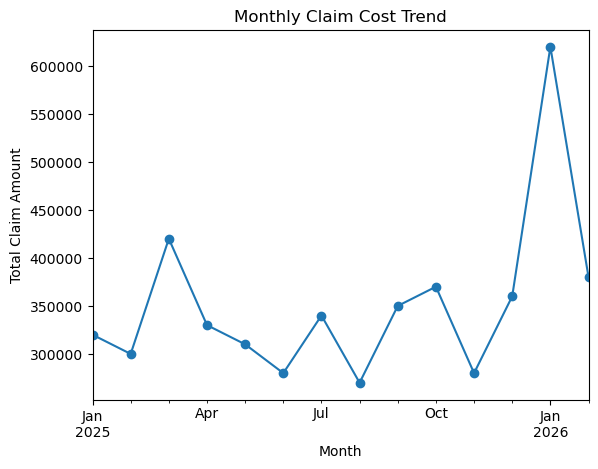

In [21]:
claims["Month"] = claims["Claim_Date"].dt.to_period("M")

monthly_claims = claims.groupby("Month")["Claim_Amount"].sum()

plt.figure()
monthly_claims.plot(kind="line", marker="o")

plt.title("Monthly Claim Cost Trend")
plt.xlabel("Month")
plt.ylabel("Total Claim Amount")

plt.show()

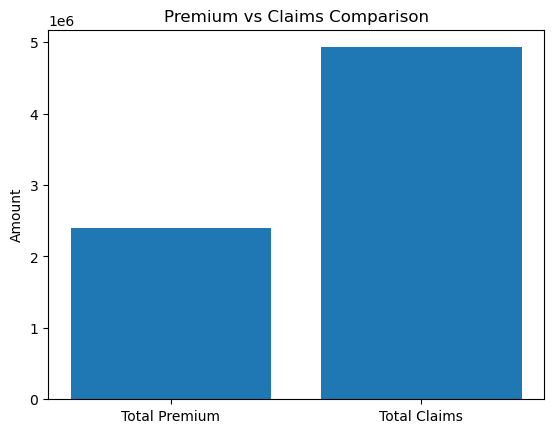

In [22]:
total_premium = policy["Premium"].sum()
total_claims = claims["Claim_Amount"].sum()

data = [total_premium, total_claims]
labels = ["Total Premium", "Total Claims"]

plt.figure()
plt.bar(labels, data)

plt.title("Premium vs Claims Comparison")
plt.ylabel("Amount")

plt.show()

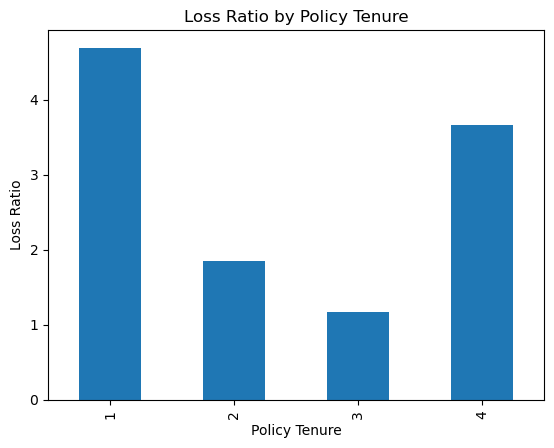

In [23]:
merged = pd.merge(policy, claims, on=["Customer_ID","Vehicle_ID"], how="left")

loss_data = merged.groupby("Policy_Tenure").agg({
    "Premium":"sum",
    "Claim_Amount":"sum"
})

loss_data["Claim_Amount"] = loss_data["Claim_Amount"].fillna(0)

loss_data["Loss_Ratio"] = loss_data["Claim_Amount"] / loss_data["Premium"]

plt.figure()
loss_data["Loss_Ratio"].plot(kind="bar")

plt.title("Loss Ratio by Policy Tenure")
plt.xlabel("Policy Tenure")
plt.ylabel("Loss Ratio")

plt.show()